## (0) Settings and Functions

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    StratifiedKFold, RepeatedStratifiedKFold, cross_validate, learning_curve, train_test_split
)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import LabelEncoder

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline
from sklearn.base import clone

from scipy.stats import friedmanchisquare
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import itertools

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from collections import Counter

In [2]:
df = pd.read_csv("../../data/treated/play_store_reviews_treated.csv")

df['TEXT_LEMMA'] = (
    df['TEXT_LEMMA']
    .fillna("")        # remove NaN
    .astype(str)       # garante string
)

df = df[df["EMOTION"] != "surprise"]

print(df.shape)
df.head(3)

(3006, 8)


,content,SENTIMENT,EMOTION,UNCLEAN_TEXT,BASE_TEXT,TEXT_NO_STOP,TEXT_LEMMA,CLEAN_TEXT
0,app shope razoá apes fácil utiliz apresent alg...,positive,sadness,app shope razoá apes fácil utiliz apresent alg...,app shope razoa apes facil utiliz apresent alg...,app shope razoa apes facil utiliz apresent alg...,app shope razoa apes facil utiliz apresent alg...,app shope razoa apes facil utiliz apresent alg...
1,app bem otimiz fácil visual produt ped rastrei...,positive,sadness,app bem otimiz fácil visual produt ped rastrei...,app bem otimiz facil visual produt ped rastrei...,app otimiz facil visual produt ped rastrei int...,app bem otimiz facil visual produt ped rastrar...,app otimiz facil visual produt ped rastrar int...
2,app bom prát fácil entend porém algum vend man...,positive,sadness,app bom prát fácil entend porém algum vend man...,app bom prat facil entend porem algum vend man...,app prat facil entend porem algum vend mand pr...,app bom prat facil entend porem algum vend man...,app prat facil entend porem algum vend mand pr...


In [3]:
def avaliar_cv(model, X_train, y_train, n_splits=5, n_repeats=6):
    rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

    # macro: trata todas as classes igualmente (classes raras importam tanto quanto classes frequentes)
    # weighted: melhor se houver desbalanceamento (penaliza menos erros em classes raras)
    scoring = {
        'accuracy': 'accuracy',
        'precision_macro': 'precision_macro',
        'recall_macro': 'recall_macro',
        'f1_macro': 'f1_macro',
        'f1_weighted': 'f1_weighted',
        'f1_micro': 'f1_micro',
    }

    results = cross_validate(
        model,
        X_train,
        y_train,
        cv=rskf,
        scoring=scoring,
        n_jobs=-1
    )

    accuracy_scores = results['test_accuracy']
    precision_scores = results['test_precision_macro']
    recall_scores  = results['test_recall_macro']
    f1_macro_scores = results['test_f1_macro']
    f1_weighted_scores = results['test_f1_weighted']
    f1_micro_scores = results['test_f1_micro']

    return {
        "Accuracy":  (accuracy_scores.mean(),  accuracy_scores.std(),  accuracy_scores),
        "Precision_macro": (precision_scores.mean(), precision_scores.std(), precision_scores),
        "Recall_macro":  (recall_scores.mean(),  recall_scores.std(),  recall_scores),
        "F1_macro":   (f1_macro_scores.mean(),   f1_macro_scores.std(),   f1_macro_scores),
        "F1_weighted":   (f1_weighted_scores.mean(),   f1_weighted_scores.std(),   f1_weighted_scores),
        "F1_micro":   (f1_micro_scores.mean(),   f1_micro_scores.std(),   f1_micro_scores),
    }

def plotar_learning_curve(model, X_train, y_train, model_name, cv=5, scoring='f1_macro'):
    train_sizes, train_scores, valid_scores = learning_curve(
        model,
        X_train,
        y_train,
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=42),
        train_sizes=np.linspace(0.3, 1.0, 10),
        scoring=scoring
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    valid_mean = valid_scores.mean(axis=1)
    valid_std = valid_scores.std(axis=1)

    plt.figure(figsize=(8,6))
    plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Score")
    plt.plot(train_sizes, valid_mean, 'o-', color="orange", label="Validation Score")

    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
    plt.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, alpha=0.1, color="orange")

    plt.title(f"Learning Curve - {model_name}")
    plt.xlabel("Training Set Size")
    plt.ylabel(scoring)
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_feature_importance_top_k(model, feature_names, k=15, model_name="Model"):
    clf = model[-1] if hasattr(model, "__getitem__") else model

    if not hasattr(model, "feature_importances_"):
        raise ValueError("The model does not have feature_importances_.") 
    
    importances = clf.feature_importances_
    idx_sorted = np.argsort(importances)[::-1][:k]
    
    # Plot 
    plt.figure(figsize=(10, 6)) 
    plt.barh(range(k), importances[idx_sorted][::-1]) 
    plt.yticks(range(k), np.array(feature_names)[idx_sorted][::-1])
    plt.title(f"Top-{k} Feature Importances - {model_name}")
    plt.xlabel("Importance") 
    plt.tight_layout() 
    plt.show()

## (1) Predict SMOTE

In [4]:
X_text = df['TEXT_LEMMA']

le = LabelEncoder()
y = le.fit_transform(df['EMOTION'])

X_text_train, X_text_aux, y_train, y_aux = train_test_split(
    X_text, y,
    train_size=0.70,
    random_state=42,
)

X_text_dev, X_text_test, y_dev, y_test = train_test_split(
    X_text_aux, y_aux,
    train_size=0.50,
    random_state=42,
)

print(X_text_train.shape, X_text_dev.shape, X_text_test.shape)

(2104,) (451,) (451,)


Distribuição original:
sadness : 599
disgust : 666
anger : 522
neutral : 61
happiness : 219
fear : 37


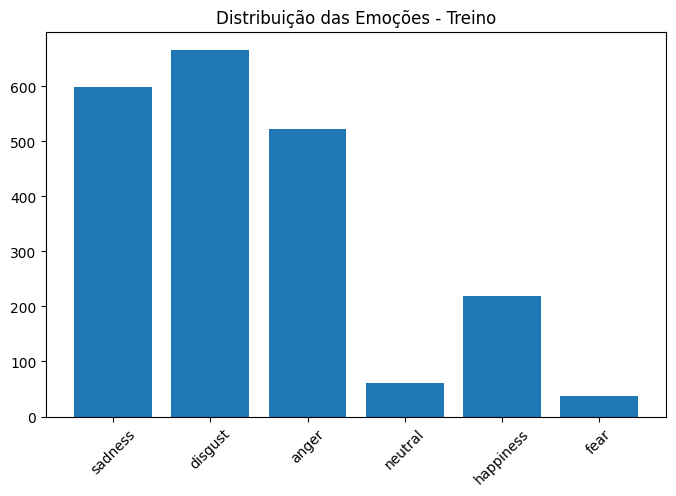

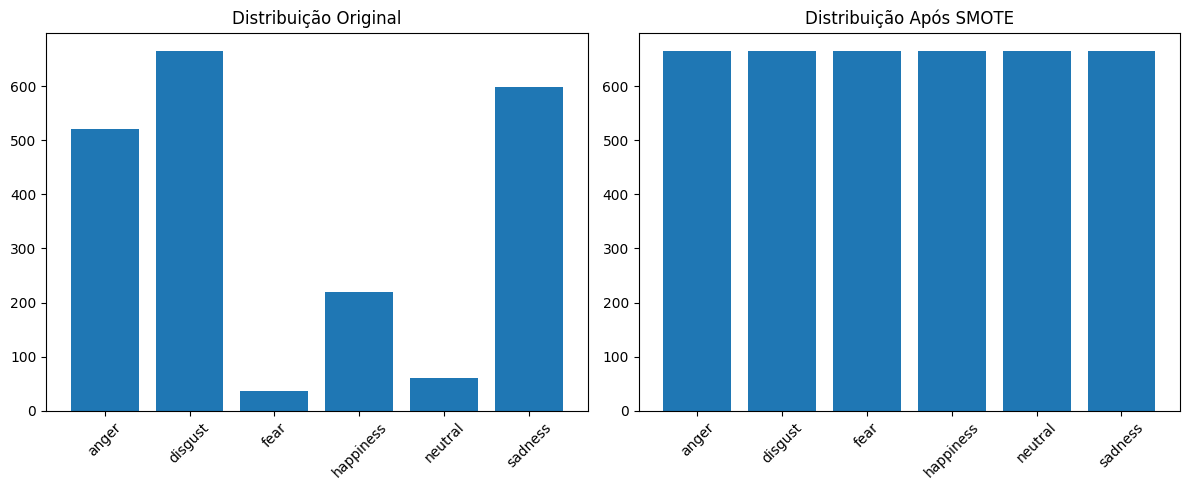

In [5]:
# Contagem das classes
counts = Counter(y_train)

# Converter índices para nomes reais
labels = [le.inverse_transform([i])[0] for i in counts.keys()]
values = counts.values()

print("Distribuição original:")
for label, count in zip(labels, values):
    print(label, ":", count)

# Gráfico
plt.figure(figsize=(8,5))
plt.bar(labels, values)
plt.title("Distribuição das Emoções - Treino")
plt.xticks(rotation=45)
plt.show()

vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(X_text_train)

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_tfidf, y_train)

# Contagens
original_counts = Counter(y_train)
resampled_counts = Counter(y_res)

labels = le.classes_

plt.figure(figsize=(12,5))

# Original
plt.subplot(1,2,1)
plt.bar(labels, [original_counts[i] for i in range(len(labels))])
plt.title("Distribuição Original")
plt.xticks(rotation=45)

# Após SMOTE
plt.subplot(1,2,2)
plt.bar(labels, [resampled_counts[i] for i in range(len(labels))])
plt.title("Distribuição Após SMOTE")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



Running model: LogisticRegression


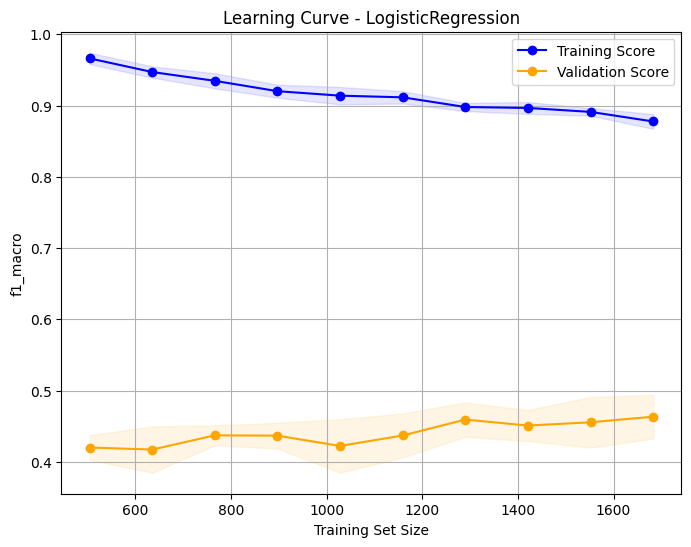


Running model: RidgeClassifier


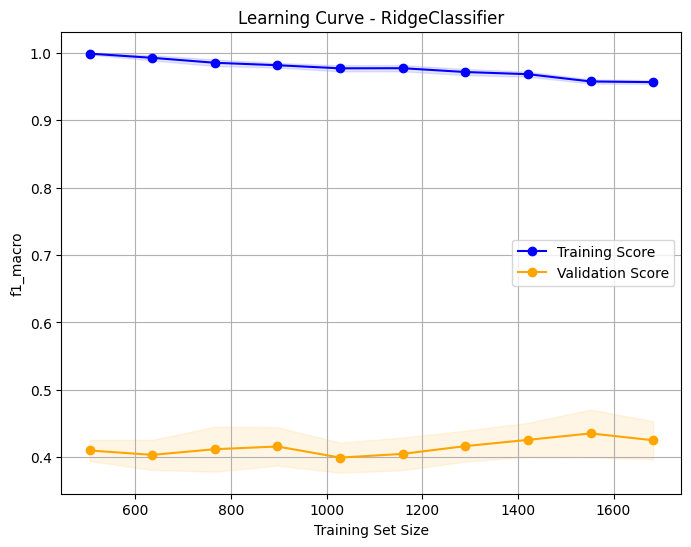


Running model: LinearSVC


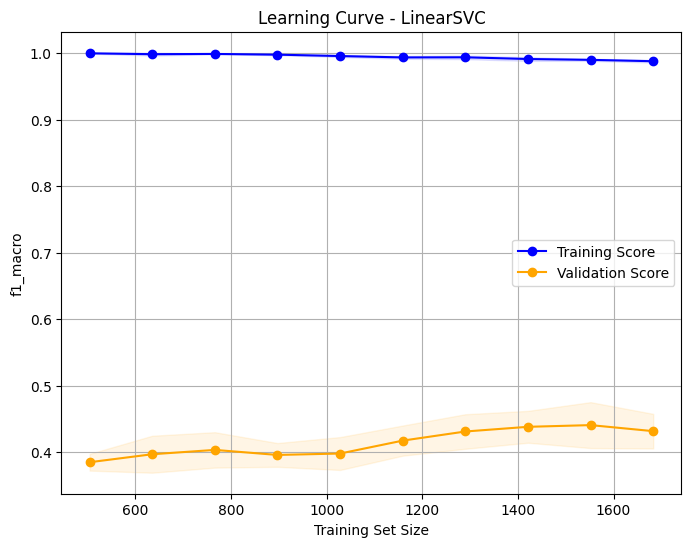


Running model: RandomForest


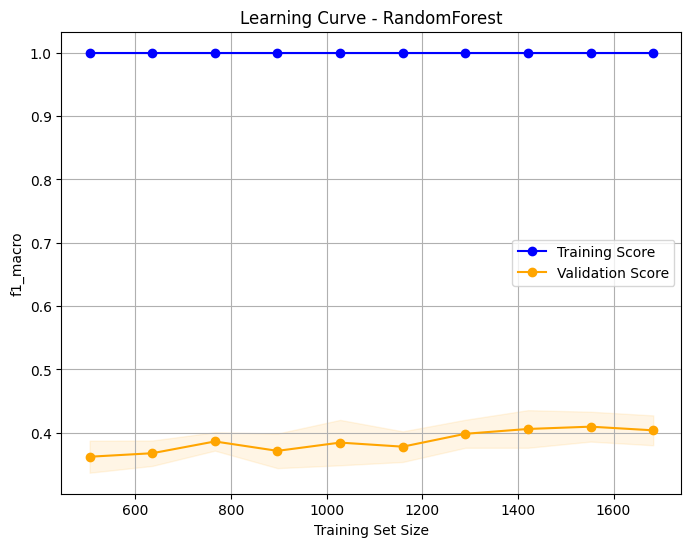


Running model: XGBClassifier


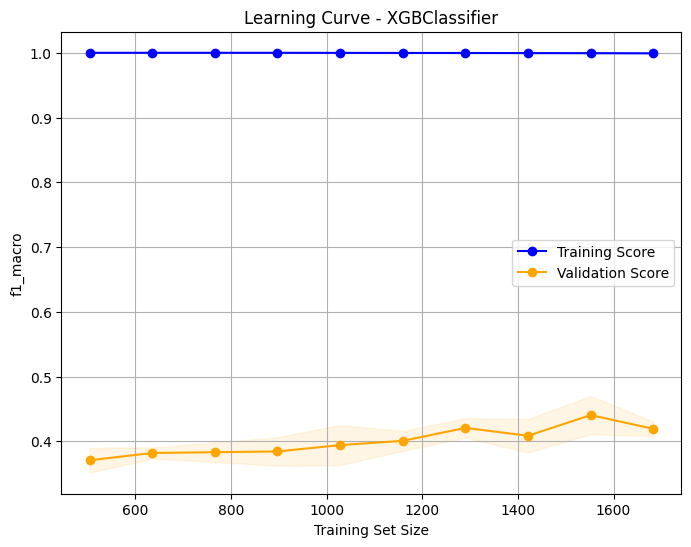

Best model: LogisticRegression


In [6]:
models_for_testing = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "RidgeClassifier": RidgeClassifier(random_state=42),
    "LinearSVC": OneVsRestClassifier(LinearSVC(random_state=42)),
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBClassifier": XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        verbosity=0
    )
}

results = []

def run_predictions(name, model, X_text_train, y_train):
    print("\n" + "=" * 80)
    print(f"Running model: {name}")
    print("=" * 80)

    pipe = ImbPipeline([
        ("tfidf", TfidfVectorizer()),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])

    cv_res = avaliar_cv(clone(pipe), X_text_train, y_train, n_splits=5, n_repeats=6)

    plotar_learning_curve(clone(pipe), X_text_train, y_train, model_name=name, cv=5, scoring="f1_macro")

    results.append({
        "Model": name,

        "CV_Accuracy_mean":  cv_res["Accuracy"][0],
        "CV_Accuracy_std":   cv_res["Accuracy"][1],
        "CV_Accuracy_all":   cv_res["Accuracy"][2],

        "CV_Precision_macro_mean":  cv_res["Precision_macro"][0],
        "CV_Precision_macro_std":   cv_res["Precision_macro"][1],
        "CV_Precision_macro_all":   cv_res["Precision_macro"][2],

        "CV_Recall_macro_mean":  cv_res["Recall_macro"][0],
        "CV_Recall_macro_std":   cv_res["Recall_macro"][1],
        "CV_Recall_macro_all":   cv_res["Recall_macro"][2],

        "CV_F1_macro_mean":  cv_res["F1_macro"][0],
        "CV_F1_macro_std":   cv_res["F1_macro"][1],
        "CV_F1_macro_all":   cv_res["F1_macro"][2],

        "CV_F1_weighted_mean":  cv_res["F1_weighted"][0],
        "CV_F1_weighted_std":   cv_res["F1_weighted"][1],
        "CV_F1_weighted_all":   cv_res["F1_weighted"][2],

        "CV_F1_micro_mean":  cv_res["F1_micro"][0],
        "CV_F1_micro_std":   cv_res["F1_micro"][1],
        "CV_F1_micro_all":   cv_res["F1_micro"][2],
    })

for name, model in models_for_testing.items():
    run_predictions(name, model, X_text_train, y_train)

df_results = pd.DataFrame(results)
best_model = df_results.sort_values(by="CV_F1_weighted_mean", ascending=False).iloc[0]["Model"]
print("Best model:", best_model)

In [7]:
def format_results(df):
    formatted_df = df.copy()

    for metric in ["Accuracy", "Precision_macro", "Recall_macro", "F1_macro", "F1_weighted", "F1_micro"]:
        mean_col = f"CV_{metric}_mean"
        std_col = f"CV_{metric}_std"

        formatted_df[metric] = (
            formatted_df[mean_col].round(4).astype(str)
            + " ± "
            + formatted_df[std_col].round(4).astype(str)
        )

        # Remove as colunas originais
        formatted_df = formatted_df.drop(columns=[mean_col, std_col])

    # reorganiza colunas
    cols = ["Model", "Accuracy", "Precision_macro", "Recall_macro", "F1_macro", "F1_weighted", "F1_micro"]
    return formatted_df[cols]

df_results.to_csv("../../data/out/balanced/balanced_08_PlayStoreReviews_TFIDF.csv")
formatted_df = format_results(df_results)
formatted_df.style.hide(axis="index")

Model,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,F1_micro
LogisticRegression,0.5902 ± 0.0173,0.475 ± 0.0316,0.4684 ± 0.0259,0.4671 ± 0.026,0.5887 ± 0.0164,0.5902 ± 0.0173
RidgeClassifier,0.5583 ± 0.0178,0.4332 ± 0.0314,0.4447 ± 0.0315,0.4366 ± 0.0309,0.5583 ± 0.0178,0.5583 ± 0.0178
LinearSVC,0.56 ± 0.0175,0.4378 ± 0.0321,0.4285 ± 0.021,0.4298 ± 0.0234,0.5565 ± 0.0172,0.56 ± 0.0175
RandomForest,0.5829 ± 0.0229,0.4831 ± 0.0646,0.4038 ± 0.0258,0.4151 ± 0.0309,0.5697 ± 0.0232,0.5829 ± 0.0229
XGBClassifier,0.5826 ± 0.0229,0.4782 ± 0.0569,0.4159 ± 0.0244,0.4297 ± 0.0301,0.5729 ± 0.0224,0.5826 ± 0.0229


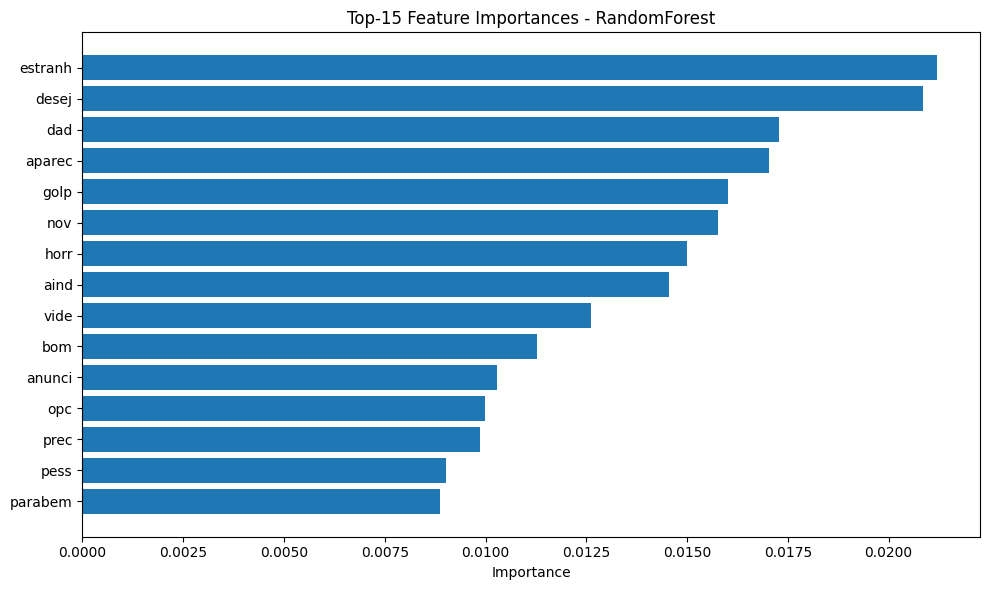

In [8]:
pipe_rf = ImbPipeline([
    ("tfidf", TfidfVectorizer()),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(random_state=42))
])
pipe_rf.fit(X_text_train, y_train)

feature_names = pipe_rf["tfidf"].get_feature_names_out()
plot_feature_importance_top_k(pipe_rf["model"], feature_names, k=15, model_name="RandomForest")

## (2) Significance Tests

In [9]:
rows = []

for _, row in df_results.iterrows():
    model = row["Model"]
    for score in row["CV_F1_macro_all"]:
        rows.append({
            "Model": model,
            "F1_macro": score
        })

df_long = pd.DataFrame(rows)

df_pivot = df_long.pivot_table(
    index=df_long.groupby("Model").cumcount(),
    columns="Model",
    values="F1_macro"
)

stat, p_value = friedmanchisquare(
    *[df_pivot[col].values for col in df_pivot.columns]
)

print(f"Friedman chi2 = {stat:.4f}") # p >= 0.05 -> there is no overall statistical difference                    
print(f"p-value = {p_value:.6f}") # p < 0.05 -> at least one model is statistically different

alpha = 0.05
results_wilcoxon = []

models = df_pivot.columns.tolist()

for m1, m2 in itertools.combinations(models, 2):
    stat, p = wilcoxon(df_pivot[m1], df_pivot[m2])
    results_wilcoxon.append({
        "Model_1": m1,
        "Model_2": m2,
        "p_value": p,
    })

df_wilcoxon = pd.DataFrame(results_wilcoxon)

df_wilcoxon["p_corrected"] = multipletests(
    df_wilcoxon["p_value"],
    method="holm"
)[1]

df_wilcoxon["Significant"] = df_wilcoxon["p_corrected"] < alpha

df_wilcoxon.style.hide(axis="index")

Friedman chi2 = 49.9467
p-value = 0.000000


Model_1,Model_2,p_value,p_corrected,Significant
LinearSVC,LogisticRegression,0.000000,0.000000,True
LinearSVC,RandomForest,0.019661,0.078643,False
LinearSVC,RidgeClassifier,0.060565,0.181696,False
LinearSVC,XGBClassifier,0.903226,0.903226,False
LogisticRegression,RandomForest,0.000000,0.000000,True
LogisticRegression,RidgeClassifier,0.000000,0.000004,True
LogisticRegression,XGBClassifier,0.000001,0.000010,True
RandomForest,RidgeClassifier,0.001583,0.009500,True
RandomForest,XGBClassifier,0.015460,0.077300,False
RidgeClassifier,XGBClassifier,0.271006,0.542011,False


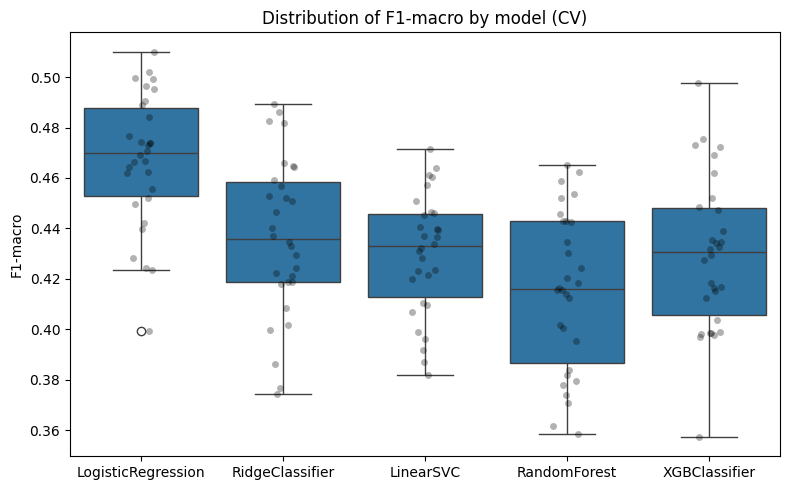

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_long,
    x="Model",
    y="F1_macro"
)
sns.stripplot(
    data=df_long,
    x="Model",
    y="F1_macro",
    color="black",
    alpha=0.3
)

plt.title("Distribution of F1-macro by model (CV)")
plt.ylabel("F1-macro")
plt.xlabel("")
plt.tight_layout()
plt.show()